<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml10_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree(의사결정 나무)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_validate, cross_val_score  # 교차 검증
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV  # 하이퍼 파라미터 튜닝

# 데이터 셋 준비

wine 데이터 셋 - red vs white wine 분류

In [2]:
file_path = 'https://bit.ly/wine_csv_data'
# https://raw.githubusercontent.com/rickiepark/hg-mldl/master/wine.csv

In [3]:
wine_df = pd.read_csv(file_path)

In [4]:
wine_df.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [5]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


# 데이터 탐색

In [6]:
wine_df.describe()  # 기술 통계량

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [12]:
wine_df['class'].unique()  # 범주(카테고리)

array([0., 1.])

In [14]:
wine_df['class'].value_counts()  #> class 0 = red wine, class 1 = white wine

,count
class,
1.0,4898
0.0,1599


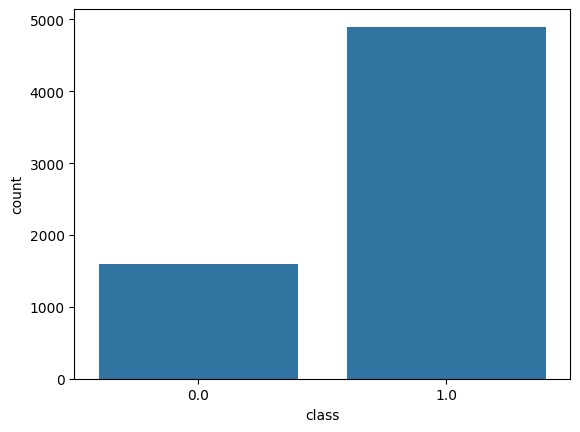

In [13]:
sns.countplot(data=wine_df, x='class')
plt.show()

*   3개 변수(alcohol, sugar, pH) 히스토그램
*   pairplot(각 변수들의 상관관계)